<a href="https://colab.research.google.com/github/RobBurnap/Bioinformatics-MICR4203-MICR5203/blob/main/notebooks/NB04_cytochrome_alignment_conservation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RobBurnap/Bioinformatics-MICR4203-MICR5203/blob/main/notebooks/NB04_cytochrome_alignment_conservation.ipynb)

# NB04 — Cytochrome alignment and conservation
**MICR4203 / MICR5203 · Fall 2026 · Version 1.2**

Save a copy in Drive before starting. Run cells from top to bottom, then complete the report questions. This notebook combines the pairwise-alignment and guide-tree lesson from NB06 with a completed conservation-analysis workflow for NB07.

**Biological question:** Which cytochrome alignment positions are conserved, and how reliable is that conclusion?

You will compare sequences, interpret a guide tree, examine an instructor-curated multiple-sequence alignment (MSA), and compare three column scores and a sequence logo. Figures export automatically as **300-dpi PNG**, plus SVG and PDF. All positions are **1-based alignment columns**, unless labeled as reference-residue positions.

**Data scope:** The original course panel contains seven **synthetic cytochrome-c-inspired teaching homologs**, not measured species observations. We inspect the curated MSA; the pairwise alignments and tree calculated here do **not** generate that MSA. An optional MAFFT extension below generates a new alignment.

**Learning goals:** explain N(N−1)/2 comparisons and D=1−I; distinguish a guide tree from an evolutionary inference; identify conserved, variable, and gap-rich columns; interpret residue colors and sequence logos; prepare figures with evidence-based captions.

**Canvas submission:** Enter answers and captions in the PDF submission form at the end. Generate and upload **one final PDF**. Keep the notebook and analysis files for your own records.

### Student view
Most Python code is collapsed so you can focus on instructions, controls, and figures. Run each titled cell using its play button. To inspect or edit the Python, use the cell’s **Show code** control or form menu. Code remains part of the notebook.

**First run:** choose **Runtime → Run all**, authorize Drive when prompted, then review the results and complete the answer form. After changing a setting, rerun that cell and the affected analysis cells.


## 1. Install tools and locate the course folders
Run once per fresh Colab session. A local Jupyter session also works; it uses a course folder in the current directory. Existing input files are preserved. Each run gets its own output folder.


In [1]:
# @title Set up tools and connect Drive
%pip install -q biopython matplotlib pandas numpy logomaker reportlab pypdf ipywidgets
from pathlib import Path
from datetime import datetime
from collections import Counter
import hashlib, json, re, shutil, subprocess, sys, importlib.metadata
from urllib.request import urlretrieve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import logomaker
from Bio import Align, AlignIO, Phylo, SeqIO
from Bio.Align import substitution_matrices
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor
from IPython.display import display

NOTEBOOK_ID = 'NB04_cytochrome_alignment_conservation'
NOTEBOOK_VERSION = '1.2'
COURSE_FOLDER_NAME = 'BIOINFO4-5203-F26'
try:
    from google.colab import drive
except ImportError:
    COURSE_DIR = Path.cwd() / COURSE_FOLDER_NAME
else:
    drive.mount('/content/drive')
    candidates = [Path('/content/drive/MyDrive') / COURSE_FOLDER_NAME,
                  Path('/content/drive/MyDrive/Teaching') / COURSE_FOLDER_NAME]
    COURSE_DIR = next((p for p in candidates if p.exists()), candidates[0])
DATA_DIR = COURSE_DIR / 'Data' / NOTEBOOK_ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
OUTPUT_DIR = COURSE_DIR / 'Outputs' / NOTEBOOK_ID / RUN_ID
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Inputs:', DATA_DIR)
print('This run:', OUTPUT_DIR)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.4 MB/s eta 0:00:00
Mounted at /content/drive
Inputs: /content/drive/MyDrive/BIOINFO4-5203-F26/Data/NB04_cytochrome_alignment_conservation
This run: /content/drive/MyDrive/BIOINFO4-5203-F26/Outputs/NB04_cytochrome_alignment_conservation/20260916_024154_535851


## 2. Settings and report-image export
Keep these settings for your first run. Later, change the logo window or gap threshold and explain the effect. **GAP_THRESHOLD is an inclusive caution threshold, not a statistical significance cutoff.**

Use the fields in the next cell; you do not need to open its code. Keep gap penalties unchanged for the assigned exercise. Change GAP_THRESHOLD for the sensitivity comparison, or LOGO_START/LOGO_END to focus the logo. Run the settings cell after changing a field.


In [2]:
# @title Choose analysis and figure settings
GAP_OPEN = -10.0 # @param {type:"number"}
GAP_EXTEND = -0.5 # @param {type:"number"}
GAP_THRESHOLD = 0.10 # @param {type:"number"}
BLOCK_WIDTH = 50 # @param {type:"integer"}
LOGO_START = 1 # @param {type:"integer"}
LOGO_END = 40 # @param {type:"integer"}
assert GAP_OPEN <= 0 and GAP_EXTEND <= 0, 'Gap penalties must be nonpositive.'
assert 0 <= GAP_THRESHOLD <= 1, 'Use a gap threshold from 0 to 1.'
assert 10 <= BLOCK_WIDTH <= 60, 'Use 10–60 columns per alignment block.'
assert 1 <= LOGO_START <= LOGO_END, 'Use a positive, ordered logo window.'
FORMATS = ('png', 'svg', 'pdf')
AA = list('ACDEFGHIKLMNPQRSTVWY')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 14,
                     'svg.fonttype': 'none', 'pdf.fonttype': 42})
figure_files = []
def save_figure(fig, stem):
    for extension in FORMATS:
        path = OUTPUT_DIR / f'{stem}.{extension}'
        fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
        if path not in figure_files:
            figure_files.append(path)
    plt.show()
    plt.close(fig)
    print('Saved:', stem + '.png (+ SVG and PDF)')


## 3. Obtain and validate the same input panel used in NB06
We retain the original NB06 data location on the course repository; renumbering this notebook does not imply that the remote data were moved. Files already in NB04's Data folder take precedence, followed by files in the old NB06 folder, then a repository download. If download is unavailable, obtain the **two original FASTA files** from the instructor and place them in the printed input folder. No substitute sequences are silently created.

For a different instructor-approved panel, replace both files consistently. Validation checks unique IDs, supported amino acids, and exact agreement between ungapped aligned sequences and input sequences.


In [3]:
# @title Load and validate the cytochrome panel
UNALIGNED_PATH = DATA_DIR / 'cytochrome_c_teaching_unaligned.fasta'
ALIGNED_PATH = DATA_DIR / 'cytochrome_c_teaching_reference_alignment.fasta'
DATA_BASE_URL = ('https://raw.githubusercontent.com/RobBurnap/'
                 'Bioinformatics-MICR4203-MICR5203/main/data/NB06_msa_generation_qc/')
input_sources = {}
for path in (UNALIGNED_PATH, ALIGNED_PATH):
    old = COURSE_DIR / 'Data' / 'NB06_msa_generation_qc' / path.name
    if path.exists():
        input_sources[path.name] = 'Existing NB04 input'
    elif old.exists():
        shutil.copy2(old, path)
        input_sources[path.name] = str(old)
    else:
        temporary = path.with_suffix('.download')
        try:
            urlretrieve(DATA_BASE_URL + path.name, temporary)
            temporary.replace(path)
            input_sources[path.name] = DATA_BASE_URL + path.name
        except Exception as error:
            temporary.unlink(missing_ok=True)
            raise RuntimeError(f'Obtain {path.name} from your instructor and put it in {DATA_DIR}, then rerun.') from error

records = list(SeqIO.parse(UNALIGNED_PATH, 'fasta'))
msa = AlignIO.read(ALIGNED_PATH, 'fasta')
names = [r.id for r in records]
sequences = [str(r.seq).upper() for r in records]
N = len(records)
assert N >= 2, 'At least two sequences are required.'
assert len(set(names)) == N, 'Duplicate input IDs.'
assert all(s and set(s) <= set(AA) for s in sequences), 'Input must contain the 20 standard amino acids only.'
assert len(msa) == N and len({r.id for r in msa}) == N, 'Missing or duplicate aligned IDs.'
aligned_by_id = {r.id: str(r.seq).upper() for r in msa}
assert set(aligned_by_id) == set(names), 'Aligned and unaligned IDs differ.'
for name, sequence in zip(names, sequences):
    assert set(aligned_by_id[name]) <= set(AA + ['-']), f'Unsupported aligned symbol: {name}'
    assert aligned_by_id[name].replace('-', '') == sequence, f'Sequence mismatch: {name}'
arr = np.array([list(aligned_by_id[name]) for name in names])
L = arr.shape[1]
assert L > 0
expected_pairs = N * (N - 1) // 2
print(f'{N} sequences; {expected_pairs} unique comparisons; {L} alignment columns')
if N != 7:
    print('Note: this is not the original seven-sequence panel size.')
display(pd.DataFrame({'sequence': names, 'length_aa': list(map(len, sequences))}))


7 sequences; 21 unique comparisons; 41 alignment columns


,sequence,length_aa
0,clade_A1,41
1,clade_A2,41
2,clade_A3,41
3,clade_B1,41
4,clade_B2,41
5,clade_B3,40
6,distant_C1,41


## 4. Pairwise identities and distances
Global pairwise alignment uses BLOSUM62 with affine gaps. Identity here is **identical residue–residue pairs / all residue–residue pairs**; columns containing a gap are excluded. Consequently, high identity can coexist with incomplete overlap. We also save the number of paired residues and alignment-column coverage.

**Predict:** How many comparisons are required for seven sequences? Why divide by two?


,sequence_1,sequence_2,identity,distance,alignment_score,paired_residues,paired_column_fraction
1,clade_A1,clade_A3,0.976,0.024,229.0,41,1.000
2,clade_A1,clade_B1,0.976,0.024,229.0,41,1.000
0,clade_A1,clade_A2,0.951,0.049,228.0,41,1.000
11,clade_A3,clade_B1,0.951,0.049,226.0,41,1.000
18,clade_B2,clade_B3,0.950,0.050,213.0,40,0.976
6,clade_A2,clade_A3,0.927,0.073,225.0,41,1.000
7,clade_A2,clade_B1,0.927,0.073,225.0,41,1.000
8,clade_A2,clade_B2,0.902,0.098,211.0,41,1.000
9,clade_A2,clade_B3,0.900,0.100,194.0,40,0.976
13,clade_A3,clade_B3,0.875,0.125,194.0,40,0.976


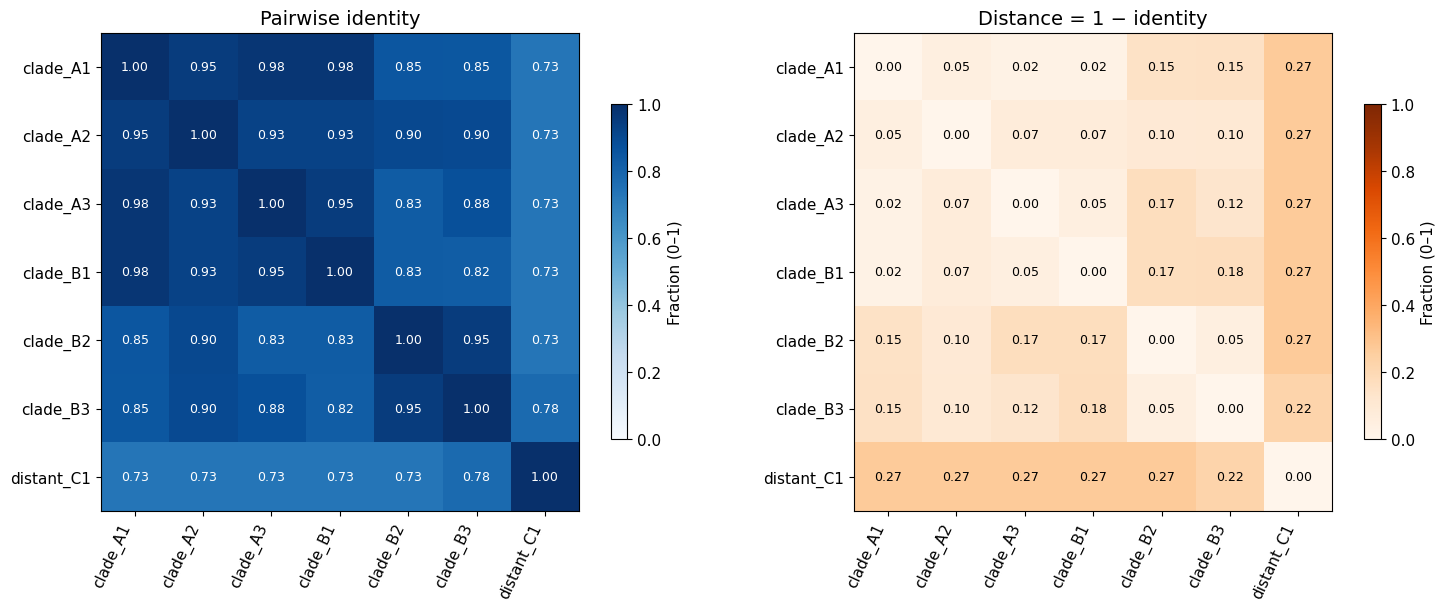

Saved: fig01_pairwise_identity_distance.png (+ SVG and PDF)


In [4]:
# @title Compare sequence pairs
pair_aligner = Align.PairwiseAligner()
pair_aligner.mode = 'global'
pair_aligner.substitution_matrix = substitution_matrices.load('BLOSUM62')
pair_aligner.open_gap_score = GAP_OPEN
pair_aligner.extend_gap_score = GAP_EXTEND
identity = pd.DataFrame(np.eye(N), index=names, columns=names)
pair_rows = []
for i in range(N):
    for j in range(i + 1, N):
        alignment = pair_aligner.align(sequences[i], sequences[j])[0]
        indices = alignment.indices
        paired = [(a, b) for a, b in zip(*indices) if a >= 0 and b >= 0]
        if not paired:
            raise ValueError('No residue pairs; identity is undefined.')
        value = sum(sequences[i][a] == sequences[j][b] for a, b in paired) / len(paired)
        identity.iloc[i, j] = identity.iloc[j, i] = value
        pair_rows.append(dict(sequence_1=names[i], sequence_2=names[j], identity=value,
                              distance=1-value, alignment_score=alignment.score,
                              paired_residues=len(paired),
                              paired_column_fraction=len(paired)/indices.shape[1]))
pairwise_results = pd.DataFrame(pair_rows)
assert len(pairwise_results) == expected_pairs
distance = 1 - identity
display(pairwise_results.sort_values('distance').round(3))
fig, axes = plt.subplots(1, 2, figsize=(15, 6), layout='constrained')
for ax, table, title, cmap in [(axes[0], identity, 'Pairwise identity', 'Blues'),
                               (axes[1], distance, 'Distance = 1 − identity', 'Oranges')]:
    im = ax.imshow(table, vmin=0, vmax=1, cmap=cmap)
    ax.set_xticks(range(N), names, rotation=65, ha='right')
    ax.set_yticks(range(N), names)
    for i in range(N):
        for j in range(N):
            v = table.iloc[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='white' if v > .6 else 'black', fontsize=9)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=.7, label='Fraction (0–1)')
save_figure(fig, 'fig01_pairwise_identity_distance')


## 5. Guide-tree reasoning
D = 1−I is an introductory distance with no correction for repeated substitutions. The neighbor-joining tree below visualizes those distances. **It was not used to build the curated MSA.** Its drawing orientation is not an inferred evolutionary root; negative branch estimates can occur with these simple distances.

Classical progressive alignment joins sequences/profiles following a guide tree, and early gap decisions can persist. The closest pair is a plausible starting pair, but does not uniquely determine every algorithm's alignment order.


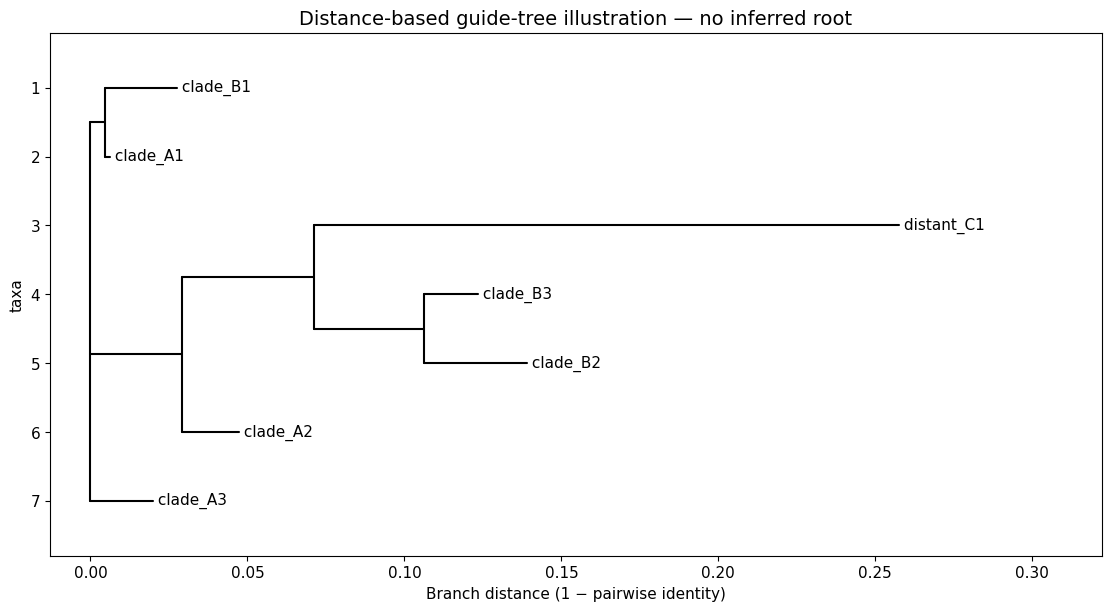

Saved: fig02_guide_tree.png (+ SVG and PDF)
Closest pair(s):


,sequence_1,sequence_2,identity,distance,alignment_score,paired_residues,paired_column_fraction
1,clade_A1,clade_A3,0.97561,0.02439,229.0,41,1.0
2,clade_A1,clade_B1,0.97561,0.02439,229.0,41,1.0


Mean distance to other sequences (a descriptive outlier measure):


,mean_distance
distant_C1,0.261077
clade_B2,0.150610
clade_B3,0.137500
clade_B1,0.126728
clade_A3,0.118394
clade_A1,0.110366
clade_A2,0.110163


In [5]:
# @title Draw the guide tree
triangle = [[float(distance.iloc[i, j]) for j in range(i + 1)] for i in range(N)]
guide_tree = DistanceTreeConstructor().nj(DistanceMatrix(names, triangle))
fig, ax = plt.subplots(figsize=(11, 6), layout='constrained')
Phylo.draw(guide_tree, axes=ax, do_show=False,
           label_func=lambda clade: clade.name if clade.is_terminal() else None)
ax.set_title('Distance-based guide-tree illustration — no inferred root')
ax.set_xlabel('Branch distance (1 − pairwise identity)')
save_figure(fig, 'fig02_guide_tree')
Phylo.write(guide_tree, str(OUTPUT_DIR / 'guide_tree.nwk'), 'newick')
print('Closest pair(s):')
display(pairwise_results.loc[np.isclose(pairwise_results.distance, pairwise_results.distance.min())])
print('Mean distance to other sequences (a descriptive outlier measure):')
display((distance.sum(axis=1)/(N-1)).sort_values(ascending=False).rename('mean_distance'))


## 6. Three views of conservation, with gap coverage
For each column, let n be the non-gap count and p(a) the frequency of residue a among those n residues.

- **Identity conservation:** max p(a). A column with a single residue and six gaps scores 1.0.
- **Entropy conservation:** 1 − H/log₂(20), where H = −Σ p(a)log₂p(a). A fixed 20-residue scale makes comparisons consistent, but seven sequences cannot sample 20 residue types. This is a descriptive score, not a significance test.
- **Occupancy-weighted identity:** (n/N) × max p(a), equivalent to the most common residue count divided by N. This deliberately penalizes missing coverage; it is not a substitute for a model of evolution.

An all-gap column has undefined identity/entropy (NaN) and weighted identity 0. Tied consensus residues are shown explicitly; the displayed consensus chooses the alphabetically first tied residue. Scores are unweighted: closely related or duplicated sequences can bias them.


In [6]:
# @title Calculate conservation and gap coverage
rows, probability_rows = [], []
reference_name = names[0]
reference_position = 0
for j in range(L):
    counts = Counter(arr[:, j][arr[:, j] != '-'])
    n = sum(counts.values())
    p = np.array([counts.get(a, 0)/n if n else 0 for a in AA])
    nonzero = p[p > 0]
    entropy = float(-np.sum(nonzero*np.log2(nonzero))) if n else np.nan
    top = max(counts.values()) if n else 0
    tied = sorted(a for a, count in counts.items() if count == top)
    if arr[0, j] != '-':
        reference_position += 1
    rows.append(dict(column_1_based=j+1, reference_id=reference_name,
                     reference_position=reference_position if arr[0, j] != '-' else None,
                     consensus=tied[0] if tied else '-', consensus_ties='/'.join(tied),
                     non_gap_count=n, occupancy=n/N, gap_fraction=1-n/N,
                     identity_conservation=top/n if n else np.nan,
                     entropy_bits=entropy,
                     entropy_conservation=1-entropy/np.log2(20) if n else np.nan,
                     occupancy_weighted_identity=top/N))
    probability_rows.append(p)
qc = pd.DataFrame(rows)
probabilities = pd.DataFrame(probability_rows, index=np.arange(1, L+1), columns=AA)
qc['gap_caution'] = qc.gap_fraction >= GAP_THRESHOLD
display(qc.round(3).head(12))
print('Gap-rich columns:')
display(qc.loc[qc.gap_caution].round(3))


,column_1_based,reference_id,reference_position,consensus,consensus_ties,non_gap_count,occupancy,gap_fraction,identity_conservation,entropy_bits,entropy_conservation,occupancy_weighted_identity,gap_caution
0,1,clade_A1,1,G,G,7,1.0,0.0,1.000,-0.000,1.000,1.000,False
1,2,clade_A1,2,K,K,7,1.0,0.0,1.000,-0.000,1.000,1.000,False
2,3,clade_A1,3,K,K,7,1.0,0.0,0.571,1.379,0.681,0.571,False
3,4,clade_A1,4,I,I,7,1.0,0.0,0.857,0.592,0.863,0.857,False
4,5,clade_A1,5,F,F,7,1.0,0.0,0.857,0.592,0.863,0.857,False
5,6,clade_A1,6,I,I/V,7,1.0,0.0,0.429,1.449,0.665,0.429,False
6,7,clade_A1,7,L,L/M,7,1.0,0.0,0.429,1.449,0.665,0.429,False
7,8,clade_A1,8,K,K,7,1.0,0.0,1.000,-0.000,1.000,1.000,False
8,9,clade_A1,9,C,C,7,1.0,0.0,1.000,-0.000,1.000,1.000,False
9,10,clade_A1,10,S,S,7,1.0,0.0,0.714,1.149,0.734,0.714,False


Gap-rich columns:


,column_1_based,reference_id,reference_position,consensus,consensus_ties,non_gap_count,occupancy,gap_fraction,identity_conservation,entropy_bits,entropy_conservation,occupancy_weighted_identity,gap_caution
22,23,clade_A1,23,T,T,6,0.857,0.143,0.833,0.65,0.85,0.714,True


## 7. Color the alignment two ways
The first view colors residues by broad chemical class (a teaching simplification; histidine is grouped with basic residues). The second colors each occupied cell by **column identity conservation**, using a shared 0–1 scale. Gray cells are gaps; printed letters preserve exact residue identity. The consensus and numeric scores sit directly underneath each block.

**Inspect:** Find a column with chemically similar substitutions and compare it with a column that is strictly identical.


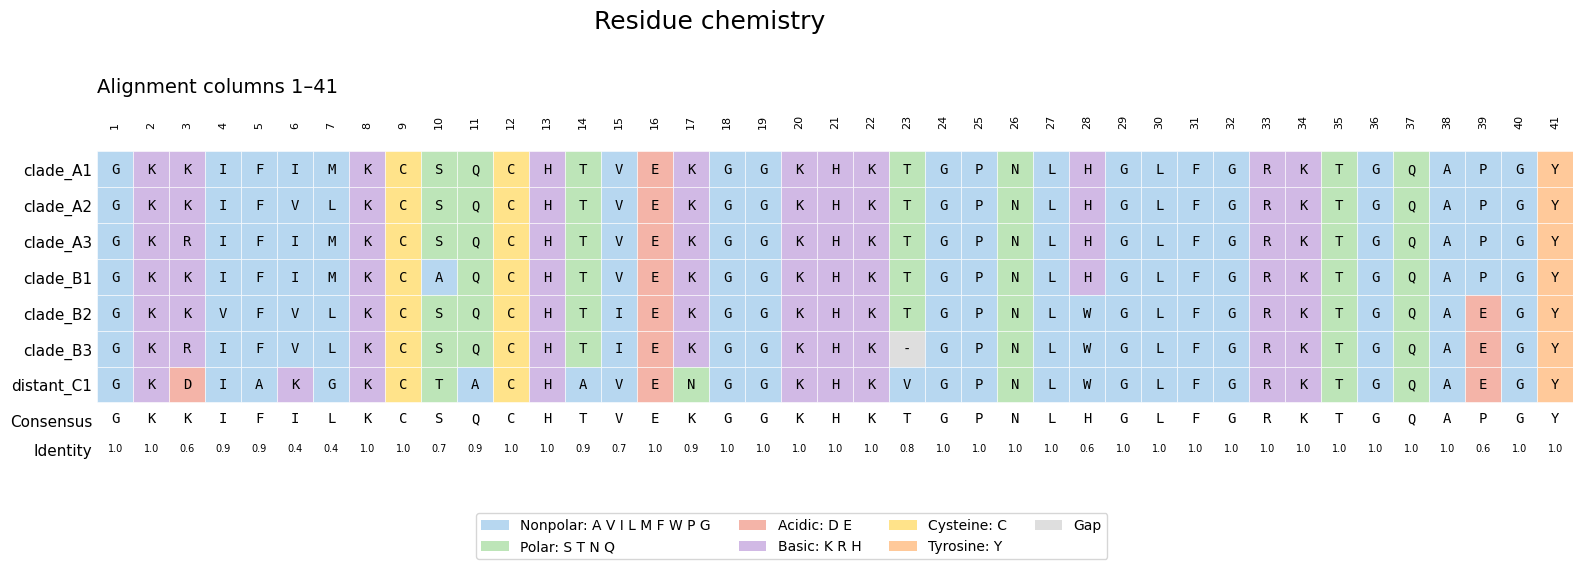

Saved: fig03_alignment_chemistry.png (+ SVG and PDF)


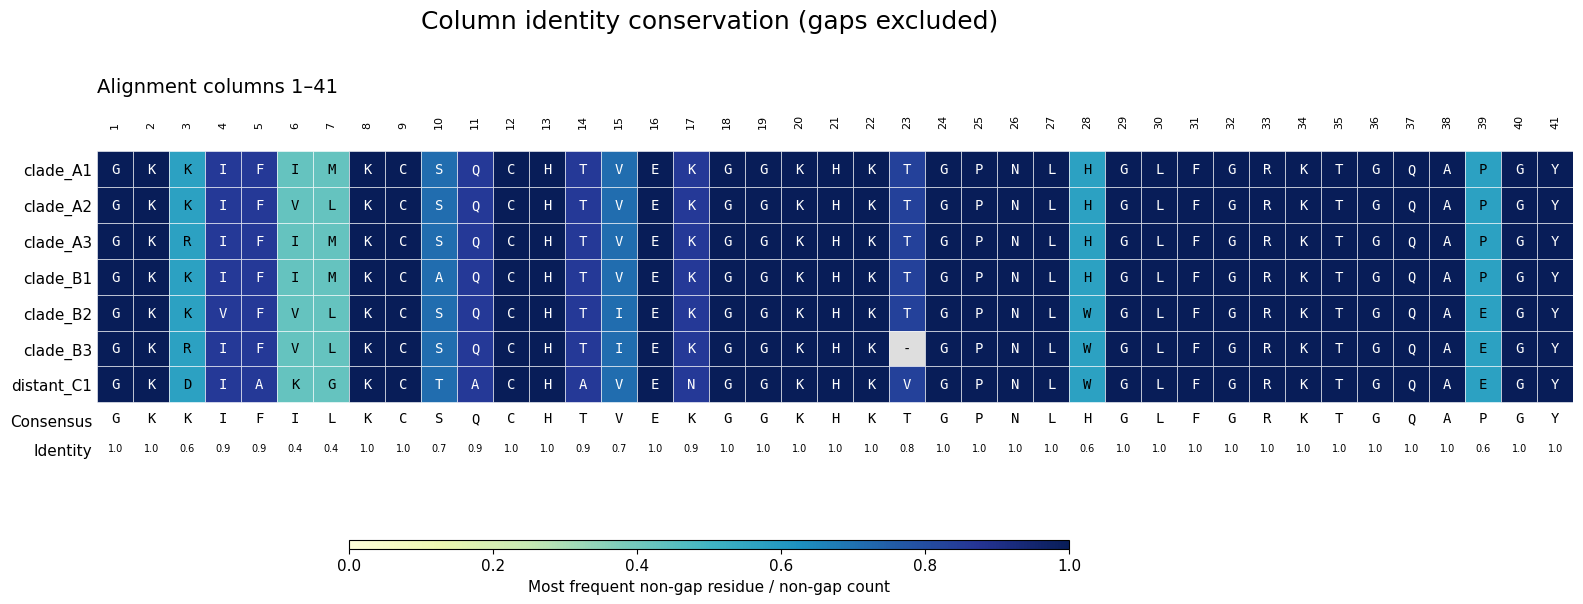

Saved: fig04_alignment_conservation.png (+ SVG and PDF)


In [7]:
# @title Display both colored alignments
groups = {'Nonpolar: A V I L M F W P G': ('AVILMFWPG', '#b7d7f0'),
          'Polar: S T N Q': ('STNQ', '#bde5b8'),
          'Acidic: D E': ('DE', '#f4b4a8'),
          'Basic: K R H': ('KRH', '#d1b9e5'),
          'Cysteine: C': ('C', '#ffe38a'), 'Tyrosine: Y': ('Y', '#ffc99a')}
residue_colors = {aa: color for residues, color in groups.values() for aa in residues}

def draw_alignment(mode):
    blocks = (L + BLOCK_WIDTH - 1) // BLOCK_WIDTH
    fig, axes = plt.subplots(blocks, 1, figsize=(18, blocks*(N*.35+3.2)), squeeze=False)
    for block, ax in enumerate(axes[:, 0]):
        start, end = block*BLOCK_WIDTH, min((block+1)*BLOCK_WIDTH, L)
        for i in range(N):
            for j in range(start, end):
                aa = arr[i, j]
                value = qc.iloc[j].identity_conservation
                color = '#dedede' if aa == '-' else (residue_colors[aa] if mode == 'chemistry' else plt.cm.YlGnBu(value))
                ax.add_patch(Rectangle((j-start-.5, i-.5), 1, 1, facecolor=color, edgecolor='white', linewidth=.4))
                ink = 'white' if mode == 'score' and aa != '-' and value > .7 else 'black'
                ax.text(j-start, i, aa, ha='center', va='center', fontsize=10, color=ink, family='monospace')
        for j in range(start, end):
            ax.text(j-start, N+.05, qc.iloc[j].consensus, ha='center', fontsize=10, family='monospace')
            v = qc.iloc[j].identity_conservation
            ax.text(j-start, N+.85, '—' if np.isnan(v) else f'{v:.1f}', ha='center', fontsize=7)
        ax.set_yticks(list(range(N))+[N, N+.8], names+['Consensus', 'Identity'])
        ax.set_xticks(range(end-start), range(start+1, end+1), rotation=90, fontsize=8)
        ax.xaxis.tick_top()
        ax.set_xlim(-.5, end-start-.5)
        ax.set_ylim(N+1.3, -1)
        ax.set_title(f'Alignment columns {start+1}–{end}', pad=30, loc='left')
        ax.tick_params(length=0)
        for spine in ax.spines.values(): spine.set_visible(False)
    fig.suptitle('Residue chemistry' if mode == 'chemistry' else 'Column identity conservation (gaps excluded)', fontsize=18, y=.98)
    if mode == 'chemistry':
        handles = [Patch(facecolor=c, label=k) for k, (_, c) in groups.items()]
        handles.append(Patch(facecolor='#dedede', label='Gap'))
        fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10)
    else:
        cax = fig.add_axes([.3, .025, .4, .015])
        fig.colorbar(ScalarMappable(norm=Normalize(0, 1), cmap='YlGnBu'), cax=cax,
                     orientation='horizontal', label='Most frequent non-gap residue / non-gap count')
    fig.subplots_adjust(top=.76, bottom=.17, left=.16, right=.98, hspace=.8)
    save_figure(fig, 'fig03_alignment_chemistry' if mode == 'chemistry' else 'fig04_alignment_conservation')
draw_alignment('chemistry')
draw_alignment('score')


## 8. Compare conservation and gap profiles
The shared x-axis links all panels to alignment columns. Orange shading flags columns at or above the chosen gap threshold. A high conservation score with low occupancy deserves a different interpretation from a high score supported by every sequence.


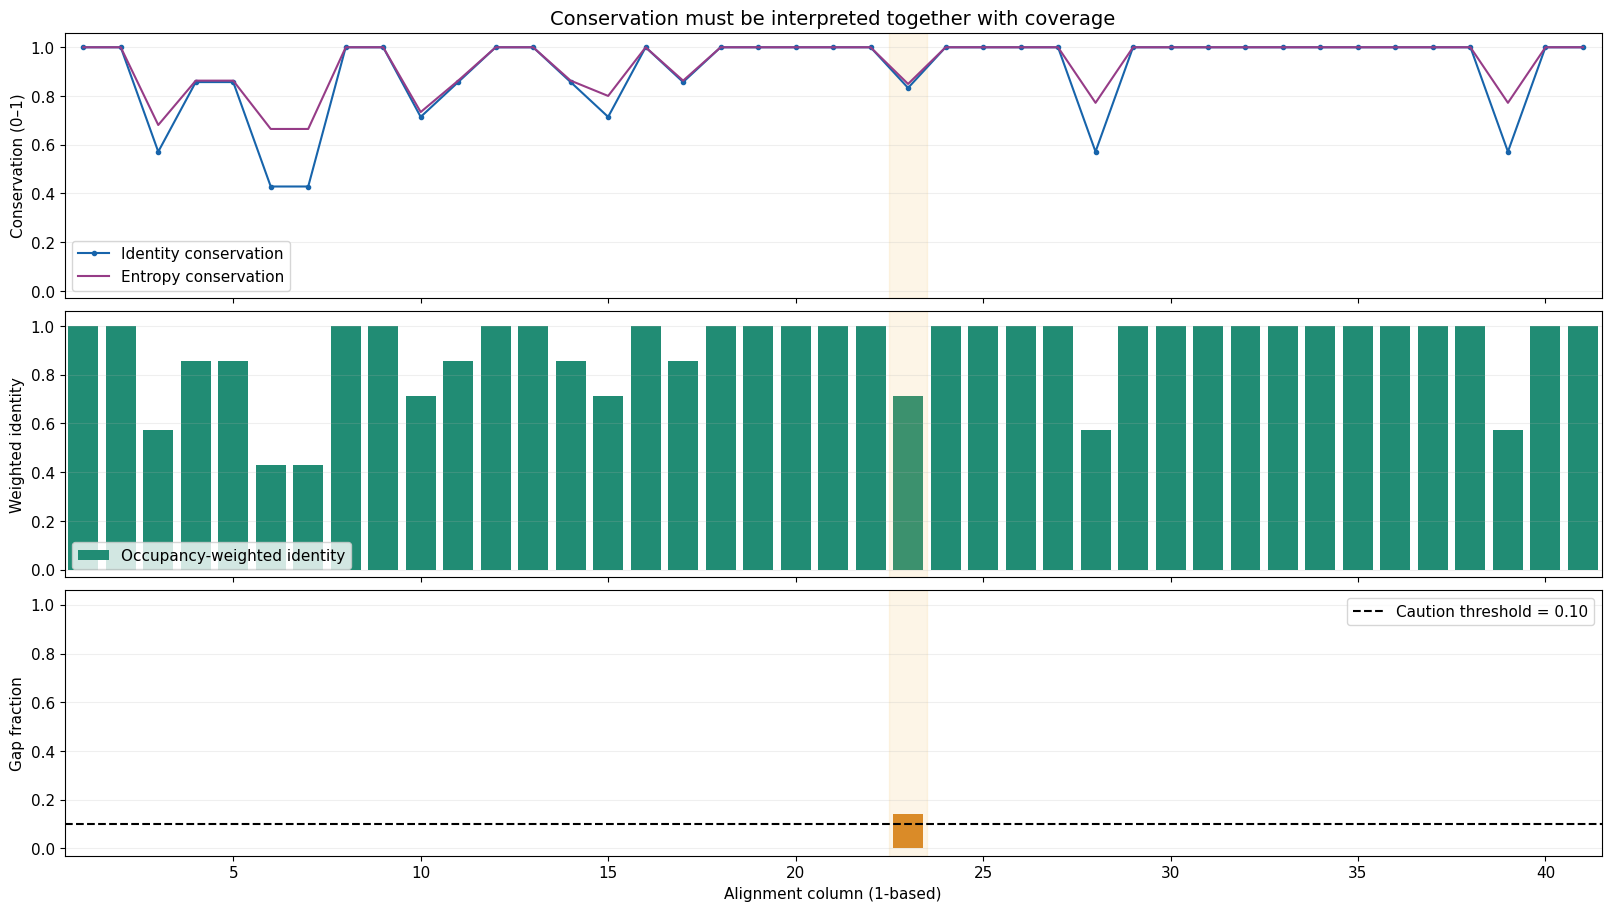

Saved: fig05_conservation_and_gaps.png (+ SVG and PDF)


In [8]:
# @title Plot conservation and gaps
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True, layout='constrained')
x = qc.column_1_based
axes[0].plot(x, qc.identity_conservation, 'o-', ms=3, label='Identity conservation', color='#1764ab')
axes[0].plot(x, qc.entropy_conservation, '-', label='Entropy conservation', color='#963c87')
axes[0].set_ylabel('Conservation (0–1)')
axes[0].legend(loc='lower left')
axes[1].bar(x, qc.occupancy_weighted_identity, color='#218c74', label='Occupancy-weighted identity')
axes[1].set_ylabel('Weighted identity')
axes[1].legend(loc='lower left')
axes[2].bar(x, qc.gap_fraction, color='#d78523')
axes[2].axhline(GAP_THRESHOLD, color='black', ls='--', label=f'Caution threshold = {GAP_THRESHOLD:.2f}')
axes[2].set_ylabel('Gap fraction')
axes[2].set_xlabel('Alignment column (1-based)')
axes[2].legend(loc='upper right')
for ax in axes:
    ax.set_ylim(-.03, 1.06)
    ax.set_xlim(.5, L+.5)
    ax.grid(axis='y', alpha=.2)
    for col in qc.loc[qc.gap_caution, 'column_1_based']:
        ax.axvspan(col-.5, col+.5, color='#f5b64c', alpha=.13)
axes[0].set_title('Conservation must be interpreted together with coverage')
save_figure(fig, 'fig05_conservation_and_gaps')


## 9. Sequence logo: which residues occur at each position?
This is a **probability logo**: each letter's height is its frequency among non-gap residues. An occupied column sums to 1, whether supported by one sequence or all sequences. An all-gap column is blank. The occupancy track below makes missing coverage visible. Colors use the same chemical groups as the alignment.

Set `LOGO_START` and `LOGO_END` above to zoom into a region; rerun this cell. This logo is **not** a background-corrected information-content logo and has no small-sample correction.


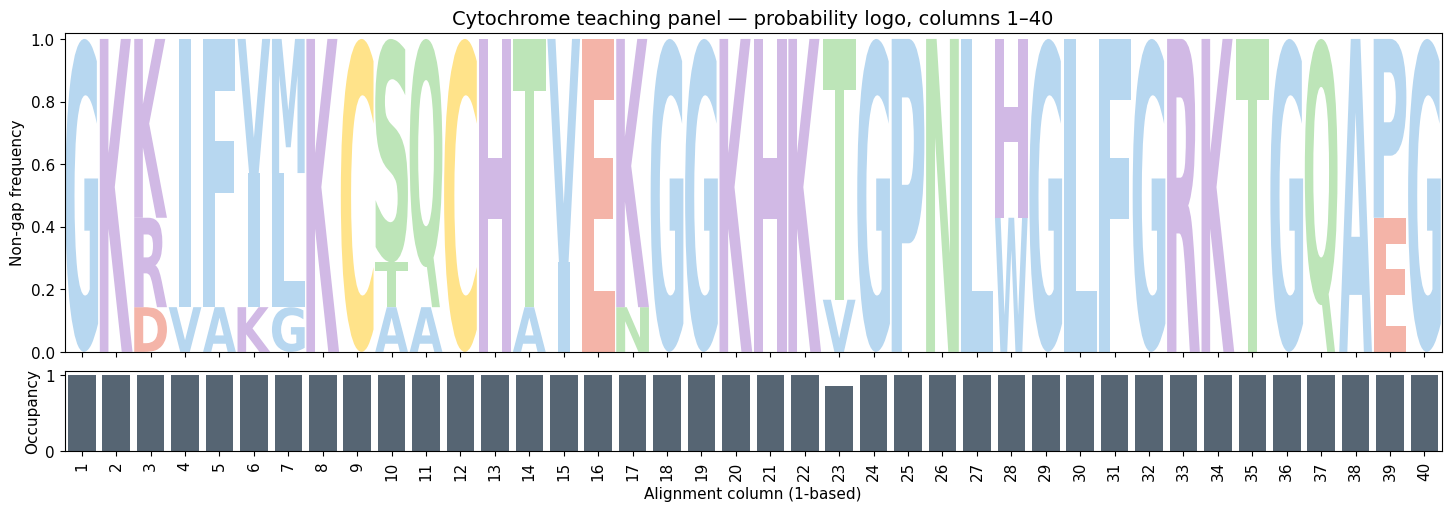

Saved: fig06_probability_logo_001_040.png (+ SVG and PDF)


In [9]:
# @title Draw the sequence logo
start, end = int(LOGO_START), min(int(LOGO_END), L)
assert 1 <= start <= end <= L, 'Choose a valid logo window.'
fig, axes = plt.subplots(2, 1, figsize=(max(10, (end-start+1)*.36), 5),
                         sharex=True, gridspec_kw={'height_ratios': [4, 1]}, layout='constrained')
logomaker.Logo(probabilities.loc[start:end], ax=axes[0], color_scheme=residue_colors)
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel('Non-gap frequency')
axes[0].set_title(f'Cytochrome teaching panel — probability logo, columns {start}–{end}')
axes[1].bar(x, qc.occupancy, color='#566573')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Occupancy')
axes[1].set_xlim(start-.5, end+.5)
axes[1].set_xticks(range(start, end+1))
axes[1].tick_params(axis='x', labelrotation=90)
axes[1].set_xlabel('Alignment column (1-based)')
save_figure(fig, f'fig06_probability_logo_{start:03d}_{end:03d}')


## 10. Locate CXXCH without mistaking a first cysteine for the motif
Search each **ungapped sequence** for C, two amino acids, C, H, then map all five residues back to alignment columns. Insertions can separate motif residues in the MSA. A consensus match alone would not establish that every sequence contains the motif.

These synthetic sequences were designed to retain a cytochrome-c-like motif. Motif conservation in this panel illustrates a pattern; it does not independently demonstrate biochemical function.


In [10]:
# @title Find and map the CXXCH motif
motif_rows = []
for name in names:
    aligned = aligned_by_id[name]
    mapping = [j+1 for j, aa in enumerate(aligned) if aa != '-']
    ungapped = aligned.replace('-', '')
    for match in re.finditer(r'(?=(C[A-Z]{2}CH))', ungapped):
        cols = mapping[match.start():match.start()+5]
        motif_rows.append(dict(sequence=name, motif=match.group(1),
                               residue_start=match.start()+1,
                               alignment_columns=','.join(map(str, cols))))
motifs = pd.DataFrame(motif_rows, columns=['sequence', 'motif', 'residue_start', 'alignment_columns'])
display(motifs)
missing = sorted(set(names)-set(motifs.sequence))
print('Sequences without CXXCH:', missing or 'None')
print('Fully occupied, strictly conserved columns:')
display(qc.loc[(qc.identity_conservation == 1) & (qc.gap_fraction == 0)])


,sequence,motif,residue_start,alignment_columns
0,clade_A1,CSQCH,9,"9,10,11,12,13"
1,clade_A2,CSQCH,9,"9,10,11,12,13"
2,clade_A3,CSQCH,9,"9,10,11,12,13"
3,clade_B1,CAQCH,9,"9,10,11,12,13"
4,clade_B2,CSQCH,9,"9,10,11,12,13"
5,clade_B3,CSQCH,9,"9,10,11,12,13"
6,distant_C1,CTACH,9,"9,10,11,12,13"


Sequences without CXXCH: None
Fully occupied, strictly conserved columns:


,column_1_based,reference_id,reference_position,consensus,consensus_ties,non_gap_count,occupancy,gap_fraction,identity_conservation,entropy_bits,entropy_conservation,occupancy_weighted_identity,gap_caution
0,1,clade_A1,1,G,G,7,1.0,0.0,1.0,-0.0,1.0,1.0,False
1,2,clade_A1,2,K,K,7,1.0,0.0,1.0,-0.0,1.0,1.0,False
7,8,clade_A1,8,K,K,7,1.0,0.0,1.0,-0.0,1.0,1.0,False
8,9,clade_A1,9,C,C,7,1.0,0.0,1.0,-0.0,1.0,1.0,False
11,12,clade_A1,12,C,C,7,1.0,0.0,1.0,-0.0,1.0,1.0,False
12,13,clade_A1,13,H,H,7,1.0,0.0,1.0,-0.0,1.0,1.0,False
15,16,clade_A1,16,E,E,7,1.0,0.0,1.0,-0.0,1.0,1.0,False
17,18,clade_A1,18,G,G,7,1.0,0.0,1.0,-0.0,1.0,1.0,False
18,19,clade_A1,19,G,G,7,1.0,0.0,1.0,-0.0,1.0,1.0,False
19,20,clade_A1,20,K,K,7,1.0,0.0,1.0,-0.0,1.0,1.0,False


## Report assignment: one PDF for Canvas

Answer the numbered questions in the form at the end of this notebook. Figures F1-F6 are selected automatically from this run; write a caption for each. Your PDF includes the questions, answers, figures, captions, and run information.

**Q1: Pairwise evidence (10 points).** Calculate N(N-1)/2 for this panel. Identify the closest pair, including ties, with identity and distance. Identify the sequence with greatest mean distance to the others. Explain one limitation of excluding gaps from identity.

**Q2: Guide tree (10 points).** Locate the closest pair on Figure F2. Explain how progressive alignment uses a guide tree, why early errors can persist, and why this tree is not a tested evolutionary history. Did this notebook use it to generate the curated MSA?

**Q3: Alignment colors (15 points).** Using F3 and F4, name one strictly conserved column, one variable column, and one gap-containing column, if present. Report residues, scores, and non-gap counts; report an absent category honestly. Explain chemical-class versus conservation-score coloring.

**Q4: Conservation and coverage (15 points).** Using F5, compare two columns with identity conservation, entropy conservation, and occupancy-weighted identity. Explain why seven identical residues differ from one residue plus six gaps, although both have identity conservation 1.0.

**Q5: Motif and logo (15 points).** Using F6, give the CXXCH motif residue position and mapped alignment columns in one named sequence. Does every sequence retain it? Explain letter height and why occupancy must be shown.

**Q6: Evidence and limitations (10 points).** Which region offers the strongest evidence of conservation? Cite column numbers and two figures. Explain limitations from synthetic design, small sample, relatedness, and alignment uncertainty.

**Q7: Sensitivity check (10 points).** Change GAP_THRESHOLD from 0.10 to 0.50 and rerun scoring and the gap profile. Record which columns change caution status and explain why their underlying scores do not change. State the final threshold used in your submitted F5.

**Rubric:** Question responses total 85 points; figure evidence and captions 10 points; complete, identifiable PDF with reproducibility information 5 points. Extensions are included only if assigned; the instructor should announce any changed weighting.

**Submit the generated final PDF only.** Your notebook, PNGs, and analysis ZIP stay in Drive unless separately requested.


## 12. Save analysis tables, alignment, and provenance
The FASTA alignment opens in Jalview or another MSA viewer. CSV/TSV tables preserve unrounded values. The ZIP contains this run's figures, tables, alignment, and provenance; keep your saved notebook for revisions. Rerunning a figure cell updates that figure within this run.


In [11]:
# @title Save analysis tables and run information
pairwise_results.to_csv(OUTPUT_DIR/'pairwise_comparisons.tsv', sep='\t', index=False)
identity.to_csv(OUTPUT_DIR/'identity_matrix.tsv', sep='\t')
distance.to_csv(OUTPUT_DIR/'distance_matrix.tsv', sep='\t')
qc.to_csv(OUTPUT_DIR/'conservation_scores.tsv', sep='\t', index=False)
probabilities.to_csv(OUTPUT_DIR/'residue_probabilities.tsv', sep='\t', index_label='column_1_based')
motifs.to_csv(OUTPUT_DIR/'motif_positions.tsv', sep='\t', index=False)
AlignIO.write(msa, str(OUTPUT_DIR/'jalview_ready_alignment.fasta'), 'fasta')
parameters = dict(notebook_id=NOTEBOOK_ID, version=NOTEBOOK_VERSION,
                  run_id=RUN_ID, sequence_count=N, alignment_columns=L,
                  unique_pairs=expected_pairs, matrix='BLOSUM62',
                  gap_open=GAP_OPEN, gap_extend=GAP_EXTEND,
                  gap_threshold=GAP_THRESHOLD, logo_window=[start, end],
                  msa_status='instructor-curated input; see input hashes',
                  data_scope='original course panel is synthetic; verify provenance of any replacement',
                  reference_id=reference_name, formats=list(FORMATS), png_dpi=300,
                  identity_definition='identical residue pairs / residue-residue pairs; gaps excluded',
                  entropy_definition='1 - H/log2(20); non-gap frequencies; no sequence weighting',
                  input_sources=input_sources,
                  input_sha256={p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in (UNALIGNED_PATH, ALIGNED_PATH)},
                  packages={p: importlib.metadata.version(p) for p in ['biopython','numpy','pandas','matplotlib','logomaker']})
(OUTPUT_DIR/'run_parameters.json').write_text(json.dumps(parameters, indent=2))
assert figure_files and all(p.exists() and p.stat().st_size > 0 for p in figure_files)
pd.DataFrame([{'file':p.name,'bytes':p.stat().st_size} for p in sorted(OUTPUT_DIR.iterdir()) if p.is_file()]).to_csv(OUTPUT_DIR/'file_manifest.tsv', sep='\t', index=False)
archive = shutil.make_archive(str(OUTPUT_DIR.parent / (RUN_ID + '_report_bundle')), 'zip', OUTPUT_DIR)
print('Report bundle:', archive)
print('PNG figures:')
for p in sorted(OUTPUT_DIR.glob('*.png')): print(' •', p.name)
# Optional Colab download: uncomment the next two lines.
# from google.colab import files
# files.download(archive)


Report bundle: /content/drive/MyDrive/BIOINFO4-5203-F26/Outputs/NB04_cytochrome_alignment_conservation/20260916_024154_535851_report_bundle.zip
PNG figures:
 • fig01_pairwise_identity_distance.png
 • fig02_guide_tree.png
 • fig03_alignment_chemistry.png
 • fig04_alignment_conservation.png
 • fig05_conservation_and_gaps.png
 • fig06_probability_logo_001_040.png


## Optional extension — generate an MSA with MAFFT
The core lesson above uses the curated reference. To generate an alignment yourself in Colab, run the next install cell, then the comparison cell. MAFFT determines its own internal alignment strategy; our displayed tree is not supplied to it. Comparison uses sets of aligned residue pairs, so changed column numbering alone does not count as disagreement. Agreement with a curated teaching alignment is not proof of biological correctness.

After this extension, rerun the export cell to update the ZIP with these additional files.


In [12]:
# @title Optional: install MAFFT (instructor extension)
# OPTIONAL: uncomment in Colab (Linux) if you are doing the extension.
# !apt-get -qq update
# !apt-get -qq install -y mafft


In [16]:
# @title Optional: compare a MAFFT alignment
RUN_MAFFT = False # @param {type:"boolean"}
if RUN_MAFFT:
    executable = shutil.which('mafft')
    if not executable:
        raise RuntimeError('Install MAFFT first, then rerun this cell.')
    result = subprocess.run([executable, '--auto', str(UNALIGNED_PATH)], capture_output=True, text=True, check=True)
    generated_path = OUTPUT_DIR/'mafft_alignment.fasta'
    generated_path.write_text(result.stdout)
    (OUTPUT_DIR/'mafft_log.txt').write_text(result.stderr)
    generated = AlignIO.read(generated_path, 'fasta')
    generated_dict = {r.id: str(r.seq).upper() for r in generated}
    assert len(generated) == N and set(generated_dict) == set(names)
    assert all(generated_dict[n].replace('-', '') == s for n, s in zip(names, sequences))
    def residue_pairs(aligned):
        positions = {n: 0 for n in names}
        pairs = set()
        for j in range(len(next(iter(aligned.values())))):
            occupied = []
            for name in names:
                if aligned[name][j] != '-':
                    positions[name] += 1
                    occupied.append((name, positions[name]))
            for i, a in enumerate(occupied):
                for b in occupied[i+1:]: pairs.add((a, b))
        return pairs
    reference_pairs, generated_pairs = residue_pairs(aligned_by_id), residue_pairs(generated_dict)
    union = reference_pairs | generated_pairs
    comparison = dict(reference_columns=L, mafft_columns=generated.get_alignment_length(),
                      shared_residue_pairs=len(reference_pairs & generated_pairs),
                      reference_only_pairs=len(reference_pairs-generated_pairs),
                      mafft_only_pairs=len(generated_pairs-reference_pairs),
                      pair_jaccard=len(reference_pairs & generated_pairs)/len(union) if union else None)
    (OUTPUT_DIR/'mafft_comparison.json').write_text(json.dumps(comparison, indent=2))
    display(pd.Series(comparison, name='MAFFT versus curated reference'))
else:
    print('Optional MAFFT extension skipped; core analysis is complete.')


Optional MAFFT extension skipped; core analysis is complete.


## Methods references
- [Biopython: pairwise alignment](https://biopython.org/docs/latest/Tutorial/chapter_pairwise.html)
- [Logomaker: probability-logo examples](https://logomaker.readthedocs.io/en/latest/examples.html)
- [MAFFT: command-line options](https://mafft.cbrc.jp/alignment/software/manual/manual.html)

**Exit ticket:** A conserved column is most convincing when ______. A sequence logo can conceal missing coverage because ______.


## Final step: answers and a submission PDF

1. Run the helper and form cells below. Type your name, course/section, answers, and figure captions. Answers save to the course folder when you leave a field or click **Save answers**.
2. Use **Preview draft PDF** to inspect layout while working. It is clearly labeled DRAFT.
3. Complete all required fields, then click **Generate submission PDF**. Missing answers, captions, or figures are listed rather than silently omitted.
4. Click **Download final PDF**, open it, check every page, and upload that **one PDF** in Canvas. Complete the Canvas submission confirmation.

The report generator uses its own page layout: answers flow across pages, and each figure starts on a separate landscape page with its caption below. Your saved answers remain editable in the notebook. If you revise them, generate and upload a new PDF. After rerunning the analysis, review restored answers against the new results.

The PDF contains fixed, searchable text. Students enter answers here rather than relying on PDF viewer form fields. Keep your notebook and Drive folder as your working copy.


In [14]:
# @title Prepare the PDF submission tools
REPORT_TITLE = 'NB04 - Cytochrome alignment and conservation'
REPORT_QUESTIONS = [{'id': 'Q1', 'title': 'Pairwise evidence', 'points': 10, 'prompt': 'Calculate N(N-1)/2 for this panel. Identify the closest pair, including ties, with identity and distance. Identify the sequence with greatest mean distance to the others. Explain one limitation of excluding gaps from identity.'}, {'id': 'Q2', 'title': 'Guide tree', 'points': 10, 'prompt': 'Locate the closest pair on Figure F2. Explain how progressive alignment uses a guide tree, why early errors can persist, and why this tree is not a tested evolutionary history. Did this notebook use it to generate the curated MSA?'}, {'id': 'Q3', 'title': 'Alignment colors', 'points': 15, 'prompt': 'Using F3 and F4, name one strictly conserved column, one variable column, and one gap-containing column, if present. Report residues, scores, and non-gap counts; report an absent category honestly. Explain chemical-class versus conservation-score coloring.'}, {'id': 'Q4', 'title': 'Conservation and coverage', 'points': 15, 'prompt': 'Using F5, compare two columns with identity conservation, entropy conservation, and occupancy-weighted identity. Explain why seven identical residues differ from one residue plus six gaps, although both have identity conservation 1.0.'}, {'id': 'Q5', 'title': 'Motif and logo', 'points': 15, 'prompt': 'Using F6, give the CXXCH motif residue position and mapped alignment columns in one named sequence. Does every sequence retain it? Explain letter height and why occupancy must be shown.'}, {'id': 'Q6', 'title': 'Evidence and limitations', 'points': 10, 'prompt': 'Which region offers the strongest evidence of conservation? Cite column numbers and two figures. Explain limitations from synthetic design, small sample, relatedness, and alignment uncertainty.'}, {'id': 'Q7', 'title': 'Sensitivity check', 'points': 10, 'prompt': 'Change GAP_THRESHOLD from 0.10 to 0.50 and rerun scoring and the gap profile. Record which columns change caution status and explain why their underlying scores do not change. State the final threshold used in your submitted F5.'}]
REPORT_FIGURES = [{'id': 'F1', 'title': 'Pairwise identity and distance', 'patterns': ['fig01_pairwise_identity_distance.png']}, {'id': 'F2', 'title': 'Guide tree', 'patterns': ['fig02_guide_tree.png']}, {'id': 'F3', 'title': 'Alignment colored by chemistry', 'patterns': ['fig03_alignment_chemistry.png']}, {'id': 'F4', 'title': 'Alignment colored by conservation', 'patterns': ['fig04_alignment_conservation.png']}, {'id': 'F5', 'title': 'Conservation and gaps', 'patterns': ['fig05_conservation_and_gaps.png']}, {'id': 'F6', 'title': 'Sequence logo including CXXCH', 'patterns': ['fig06_probability_logo_*.png']}]
REQUIRE_EXTENSION = False  # Instructor: set True only when an extension is assigned.

# PDF submission helper. Run this cell once before opening the answer form.
from pathlib import Path
from datetime import datetime
import json, re, hashlib
from html import escape
import ipywidgets as widgets
from IPython.display import display, clear_output, FileLink
from reportlab.platypus import (BaseDocTemplate, PageTemplate, Frame, Paragraph,
                               Spacer, Image as PDFImage, PageBreak, NextPageTemplate, KeepTogether)
from reportlab.lib.pagesizes import letter, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.lib.utils import ImageReader
from pypdf import PdfReader
import matplotlib

# Use the fonts bundled with Matplotlib so ordinary Greek symbols remain readable.
font_directory = Path(matplotlib.get_data_path()) / 'fonts' / 'ttf'
for font_name, filename in [('ReportSans','DejaVuSans.ttf'),('ReportBold','DejaVuSans-Bold.ttf')]:
    if font_name not in pdfmetrics.getRegisteredFontNames():
        pdfmetrics.registerFont(TTFont(font_name, str(font_directory / filename)))
pdfmetrics.registerFontFamily('ReportSans', normal='ReportSans', bold='ReportBold', italic='ReportSans', boldItalic='ReportBold')
REPORT_VERSION = '1.2'
REPORT_HOME = COURSE_DIR / 'Reports' / NOTEBOOK_ID
REPORT_HOME.mkdir(parents=True, exist_ok=True)
DRAFT_PATH = REPORT_HOME / 'saved_answers.json'
SUBMISSION_DIR = COURSE_DIR / 'Outputs' / NOTEBOOK_ID / 'Submissions'
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)


def plain_paragraphs(text, style):
    # Treat student input as plain text, not executable code or ReportLab markup.
    # Split real paragraphs; reportlab flows long paragraphs onto later pages.
    chunks = str(text).replace('\r\n','\n').replace('\r','\n').split('\n\n')
    return [Paragraph(escape(chunk).replace('\n','<br/>'), style) for chunk in chunks if chunk.strip()]


def report_styles():
    styles = getSampleStyleSheet()
    styles.add(ParagraphStyle(name='ReportTitle',fontName='ReportBold',fontSize=20,leading=25,spaceAfter=16))
    styles.add(ParagraphStyle(name='ReportHeading',fontName='ReportBold',fontSize=12,leading=17,spaceBefore=10,spaceAfter=7,keepWithNext=True))
    styles.add(ParagraphStyle(name='ReportText',fontName='ReportSans',fontSize=10.5,leading=15,spaceAfter=9,splitLongWords=True))
    styles.add(ParagraphStyle(name='ReportSmall',fontName='ReportSans',fontSize=8.5,leading=11,spaceAfter=4,splitLongWords=True))
    return styles


def missing_report_items(payload):
    missing=[]
    if not payload.get('student','').strip(): missing.append('Student name')
    if not payload.get('section','').strip(): missing.append('Course/section')
    for question in REPORT_QUESTIONS:
        if not payload.get('answers',{}).get(question['id'],'').strip(): missing.append(question['id']+' answer')
    if REQUIRE_EXTENSION and not payload.get('extension','').strip(): missing.append('Assigned extension answer')
    for slot in REPORT_FIGURES:
        choice=payload.get('figures',{}).get(slot['id'],{})
        filename=choice.get('file','')
        # Only use files inside this run's output folder; drafts store names, not arbitrary paths.
        if not filename or Path(filename).name!=filename or not (OUTPUT_DIR/filename).is_file():
            missing.append(slot['id']+' figure')
        if not choice.get('caption','').strip(): missing.append(slot['id']+' caption')
    return missing


def build_submission_pdf(payload, draft=False):
    missing=missing_report_items(payload)
    if missing and not draft: raise ValueError('Complete these items before generating the submission: '+', '.join(missing))
    student=payload.get('student','').strip() or 'Unnamed student'
    slug=re.sub(r'[^A-Za-z0-9_-]+','_',student).strip('_')[:70] or 'student'
    stamp=datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    base=f'{NOTEBOOK_ID}_{slug}_{"DRAFT" if draft else "SUBMISSION"}_{stamp}'
    path=SUBMISSION_DIR/(base+'.pdf')
    styles=report_styles(); story=[]
    generated=datetime.now().isoformat(timespec='seconds')
    file_fingerprints={}
    def heading(text):return Paragraph(escape(text),styles['ReportHeading'])
    def paragraphs(text,small=False):return plain_paragraphs(text,styles['ReportSmall' if small else 'ReportText'])
    def page_footer(canvas,doc):
        width,height=canvas._pagesize
        canvas.saveState();canvas.setStrokeColor(colors.HexColor('#ccd4da'))
        canvas.line(42,31,width-42,31)
        canvas.setFont('ReportSans',8)
        label=f'{NOTEBOOK_ID} | {"DRAFT - NOT FOR SUBMISSION" if draft else "Submission"}'
        canvas.drawString(42,19,label)
        canvas.drawRightString(width-42,19,f'Page {doc.page}')
        canvas.restoreState()
    doc=BaseDocTemplate(str(path),pagesize=letter,leftMargin=42,rightMargin=42,topMargin=42,bottomMargin=42,
                        title=REPORT_TITLE,author=student)
    for name,size in [('answers',letter),('figures',landscape(letter))]:
        doc.addPageTemplates(PageTemplate(id=name,pagesize=size,
            frames=[Frame(42,42,size[0]-84,size[1]-84,id=name,leftPadding=0,rightPadding=0,topPadding=0,bottomPadding=0)],onPage=page_footer))
    story.append(Paragraph(escape(REPORT_TITLE),styles['ReportTitle']))
    story += paragraphs(f'Student: {student}\nCourse/section: {payload.get("section","")}\nNotebook report version: {REPORT_VERSION}\nAnalysis run: {RUN_ID}\nPDF generated: {generated}')
    if draft:
        story.append(heading('DRAFT - NOT FOR SUBMISSION'))
        story += paragraphs('Missing items: '+(', '.join(missing) if missing else 'None. Generate the final submission PDF after reviewing.'))
    story += paragraphs('Responses and figure captions below are student-entered. Figures come from the current analysis run. This report uses numbered questions and figures for rubric-based grading.',True)
    story.append(heading('Student responses'))
    for question in REPORT_QUESTIONS:
        story.append(heading(f'{question["id"]} - {question["title"]} ({question["points"]} points)'))
        prompt_parts=paragraphs(question['prompt'],True)
        for part in prompt_parts: part.keepWithNext=True
        story += prompt_parts
        story += paragraphs(payload.get('answers',{}).get(question['id'],'').strip() or '[No answer entered]')
    if payload.get('extension','').strip() or REQUIRE_EXTENSION:
        story.append(heading('Assigned extension'))
        story += paragraphs(payload.get('extension','').strip() or '[No extension answer entered]')
    for slot in REPORT_FIGURES:
        story.extend([NextPageTemplate('figures'),PageBreak()])
        story.append(Paragraph(escape(f'{slot["id"]} - {slot["title"]}'),styles['ReportHeading']))
        item=payload.get('figures',{}).get(slot['id'],{})
        filename=item.get('file','')
        image_path=OUTPUT_DIR/filename
        if filename and Path(filename).name==filename and image_path.is_file():
            iw,ih=ImageReader(str(image_path)).getSize()
            # Dedicated landscape figure page, bounded image box, no absolute text placement.
            # Captions flow below, and continue onto another page if unusually long.
            caption_text=item.get('caption','').strip() or '[No caption entered]'
            caption_parts=paragraphs(caption_text)
            caption_height=sum(p.wrap(708,100000)[1]+p.getSpaceAfter() for p in caption_parts)
            image_height=max(260,min(402,528-34-8-34-min(caption_height,150)-25))
            scale=min(708/iw,image_height/ih)
            story.append(PDFImage(str(image_path),width=iw*scale,height=ih*scale))
            file_fingerprints[filename]=hashlib.sha256(image_path.read_bytes()).hexdigest()
        else: story += paragraphs('[Figure missing]')
        story.append(Spacer(1,8));story.append(heading('Student caption'))
        story += paragraphs(item.get('caption','').strip() or '[No caption entered]')
        story += paragraphs('Source figure: '+(filename or '[none]'),True)
    story.extend([NextPageTemplate('answers'),PageBreak(),heading('Reproducibility record')])
    story += paragraphs('Notebook: '+NOTEBOOK_ID+'\nAnalysis run: '+str(RUN_ID)+'\nReport version: '+REPORT_VERSION,True)
    metadata_path=OUTPUT_DIR/'run_parameters.json'
    if metadata_path.exists():
        metadata=json.loads(metadata_path.read_text())
        for key,value in metadata.items():
            story += paragraphs(f'{key}: {json.dumps(value,ensure_ascii=False) if isinstance(value,(dict,list)) else value}',True)
    else:
        story += paragraphs('Run parameters file was not found. Rerun the analysis export cell if it was skipped.',True)
    story += paragraphs('Figure SHA-256 identifiers:',True)
    for filename,digest in file_fingerprints.items():story += paragraphs(filename+' | SHA-256 prefix: '+digest[:16],True)
    try:
        doc.build(story)
        reader=PdfReader(path)
        if reader.get_fields():raise RuntimeError('The report unexpectedly contains interactive PDF form fields.')
        if not reader.pages:raise RuntimeError('Empty PDF.')
        snapshot=dict(payload,notebook_id=NOTEBOOK_ID,report_version=REPORT_VERSION,run_id=RUN_ID,
                      generated=generated,draft=draft,pdf_file=path.name,figure_sha256=file_fingerprints)
        path.with_suffix('.json').write_text(json.dumps(snapshot,indent=2,ensure_ascii=False))
    except Exception:
        path.unlink(missing_ok=True)
        raise
    return path


def open_answer_form():
    saved={}
    if DRAFT_PATH.exists():
        try:saved=json.loads(DRAFT_PATH.read_text())
        except (ValueError,OSError) as error:
            print('Could not load the saved draft. It has not been replaced:',error)
            raise
    student=widgets.Text(value=saved.get('student',''),description='Name:',layout=widgets.Layout(width='95%'),continuous_update=False)
    section=widgets.Text(value=saved.get('section',''),description='Course/section:',layout=widgets.Layout(width='95%'),style={'description_width':'initial'},continuous_update=False)
    answers={q['id']:widgets.Textarea(value=saved.get('answers',{}).get(q['id'],''),
        placeholder='Type your response here. Cite figure and residue/column numbers where relevant.',
        layout=widgets.Layout(width='98%',height='150px'),continuous_update=False) for q in REPORT_QUESTIONS}
    extension=widgets.Textarea(value=saved.get('extension',''),placeholder='Complete only if the instructor assigned an extension.',layout=widgets.Layout(width='98%',height='150px'),continuous_update=False)
    picks={};captions={};panels=[]
    for slot in REPORT_FIGURES:
        previous=saved.get('figures',{}).get(slot['id'],{})
        picks[slot['id']]=widgets.Dropdown(description='Figure file:',layout=widgets.Layout(width='98%'))
        captions[slot['id']]=widgets.Textarea(value=previous.get('caption',''),placeholder='Describe what this figure shows, define its colors/axes, and state relevant parameters.',layout=widgets.Layout(width='98%',height='120px'),continuous_update=False)
        panels.append(widgets.VBox([widgets.HTML('<b>'+escape(slot['title'])+'</b>'),picks[slot['id']],captions[slot['id']]]))
    status=widgets.Output();result=widgets.Output()
    state={'latest_pdf':None,'building':True,'draft':False}
    save=widgets.Button(description='Save answers')
    refresh=widgets.Button(description='Refresh figures')
    preview=widgets.Button(description='Preview draft PDF')
    generate=widgets.Button(description='Generate submission PDF',layout=widgets.Layout(width='230px'),button_style='success')
    download=widgets.Button(description='Download final PDF',disabled=True)
    def collect():
        return dict(student=student.value,section=section.value,answers={k:v.value for k,v in answers.items()},
                    extension=extension.value,figures={k:dict(file=picks[k].value or '',caption=captions[k].value) for k in picks})
    def persist(change=None):
        if state['building']:return
        data=collect();temporary=DRAFT_PATH.with_suffix('.tmp')
        temporary.write_text(json.dumps(data,indent=2,ensure_ascii=False));temporary.replace(DRAFT_PATH)
        state['latest_pdf']=None;download.disabled=True
        with status:
            clear_output(wait=True);print('Answers saved:',datetime.now().strftime('%H:%M:%S'),'| Changes require a newly generated PDF.')
    def refresh_options(button=None):
        prior=state['building'];state['building']=True
        for slot in REPORT_FIGURES:
            field=picks[slot['id']];current=field.value or saved.get('figures',{}).get(slot['id'],{}).get('file','')
            files=sorted({p.name for pattern in slot['patterns'] for p in OUTPUT_DIR.glob(pattern) if p.is_file()})
            field.options=[('No matching figure available','')]+[(f,f) for f in files]
            field.value=current if current in files else (max(files,key=lambda n:(OUTPUT_DIR/n).stat().st_mtime) if files else '')
        state['building']=prior
        if not prior:persist()
    def make_pdf(draft):
        persist()
        with result:
            clear_output(wait=True)
            try:path=build_submission_pdf(collect(),draft=draft)
            except Exception as error:
                print(str(error));return
            state['latest_pdf']=path;state['draft']=draft;download.disabled=draft
            print(('DRAFT: review only. ' if draft else 'Final PDF created. ')+str(path))
            print('Open the PDF and check every page, then upload the final PDF to Canvas.')
            display(FileLink(str(path)))
    def download_final(button):
        path=state['latest_pdf']
        if path is None or state['draft']:
            with result:print('Generate a current final PDF first.')
            return
        snapshot=json.loads(path.with_suffix('.json').read_text())
        changed=[name for name,digest in snapshot['figure_sha256'].items()
                 if not (OUTPUT_DIR/name).is_file() or hashlib.sha256((OUTPUT_DIR/name).read_bytes()).hexdigest()!=digest]
        if changed:
            state['latest_pdf']=None;download.disabled=True
            with result:print('Figures changed since PDF generation. Generate a new submission PDF:',', '.join(changed))
            return
        try:
            from google.colab import files
        except ImportError:
            with result:display(FileLink(str(path)))
        else:files.download(str(path))
    for field in [student,section,extension,*answers.values(),*captions.values(),*picks.values()]:field.observe(persist,names='value')
    save.on_click(persist);refresh.on_click(refresh_options)
    preview.on_click(lambda button:make_pdf(True));generate.on_click(lambda button:make_pdf(False));download.on_click(download_final)
    answer_panels=[widgets.VBox([widgets.HTML('<b>'+escape(q['title'])+'</b><p>'+escape(q['prompt'])+'</p>'),answers[q['id']]]) for q in REPORT_QUESTIONS]
    answer_tabs=widgets.Accordion(children=answer_panels,selected_index=0)
    for i,q in enumerate(REPORT_QUESTIONS):answer_tabs.set_title(i,f'{q["id"]}: {q["title"]}')
    figure_tabs=widgets.Accordion(children=panels,selected_index=None)
    for i,slot in enumerate(REPORT_FIGURES):figure_tabs.set_title(i,f'{slot["id"]}: {slot["title"]}')
    refresh_options();state['building']=False
    if saved:print('Saved draft loaded. Review answers and figures against this analysis run before generating a new PDF.')
    print('Answers save when you leave a field or press Save answers. Keep this notebook and its Drive folder for revisions.')
    display(widgets.VBox([student,section,widgets.HTML('<h3>Answers</h3>'),answer_tabs,
                          widgets.HTML('<h3>Figure captions</h3>'),figure_tabs,
                          widgets.HTML('<h3>Extension (only if assigned)</h3>'),extension,
                          widgets.HBox([save,refresh]),widgets.HBox([preview,generate,download]),status,result]))
    return dict(student=student,section=section,answers=answers,picks=picks,captions=captions,extension=extension,
                collect=collect,persist=persist,refresh=refresh_options,make_pdf=make_pdf,state=state,download=download)


In [15]:
# @title Open answers, captions, and PDF controls
report_form = open_answer_form()


Answers save when you leave a field or press Save answers. Keep this notebook and its Drive folder for revisions.
